# Final Project NLP

Mateo Galvis L

## 1. Packages

In [99]:
# Basic imports
import pandas as pd
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import re
import spacy
import pickle
# Enity extraction
import torch
from transformers import pipeline
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline, AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoModelForTokenClassification
from transformers.pipelines.pt_utils import KeyDataset
from collections import Counter
from datasets import load_dataset
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

In [ ]:
from google.colab import drive
# Contect to your drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Read data

In [ ]:
df_news_AI_clean_topics = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/def_news_AI_clean_topics.parquet', engine='pyarrow')

In [ ]:
display(df_news_AI_clean_topics.head(3))

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count,semantic_score,Topic_Number,Topic_Name,Probability
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482,0.205120,9,Cryptocurrency & Financial Trading,0.995980
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736,0.282888,3,Digital Media & Entertainment,0.974883
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811,0.378478,3,Digital Media & Entertainment,0.453399


In [ ]:
print('Initial dataframe shape :', df_news_AI_clean_topics.shape)
print('Columns in the dataframe :', df_news_AI_clean_topics.columns)

Initial dataframe shape : (186029, 18)
Columns in the dataframe : Index(['url', 'date', 'title', 'text', 'year', 'month', 'text_word_count',
       'title_word_count', 'clean_title', 'clean_text',
       'title_word_clean_count', 'text_word_clean_count', 'title_text_clean',
       'title_text_clean_count', 'semantic_score', 'Topic_Number',
       'Topic_Name', 'Probability'],
      dtype='object')


In [ ]:
display(df_news_AI_clean_topics.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186029 entries, 0 to 186028
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   url                     186029 non-null  object        
 1   date                    186029 non-null  datetime64[ns]
 2   title                   186029 non-null  object        
 3   text                    186029 non-null  object        
 4   year                    186029 non-null  int32         
 5   month                   186029 non-null  int32         
 6   text_word_count         186029 non-null  int64         
 7   title_word_count        186029 non-null  int64         
 8   clean_title             186029 non-null  object        
 9   clean_text              186029 non-null  object        
 10  title_word_clean_count  186029 non-null  int64         
 11  text_word_clean_count   186029 non-null  int64         
 12  title_text_clean        186029

None

In [ ]:
# 1. Check for GPU (highly recommended for 50k articles)
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Using device: GPU


In [ ]:
# Do a sample of 10% of the data to understand the process
#df_news_AI_clean_topics = df_news_AI_clean_topics.sample(frac=0.05, random_state=97)

In [ ]:
# Check missing values
print('Number of missing values:', df_news_AI_clean_topics['title_text_clean'].isna().sum())
print(len(df_news_AI_clean_topics))

Number of missing values: 0
186029


## 3. Sentiment analysis

In [ ]:
ds = load_dataset("community-datasets/per_sent")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['DOCUMENT_INDEX', 'TITLE', 'TARGET_ENTITY', 'DOCUMENT', 'MASKED_DOCUMENT', 'TRUE_SENTIMENT', 'Paragraph0', 'Paragraph1', 'Paragraph2', 'Paragraph3', 'Paragraph4', 'Paragraph5', 'Paragraph6', 'Paragraph7', 'Paragraph8', 'Paragraph9', 'Paragraph10', 'Paragraph11', 'Paragraph12', 'Paragraph13', 'Paragraph14', 'Paragraph15'],
        num_rows: 3355
    })
    test_random: Dataset({
        features: ['DOCUMENT_INDEX', 'TITLE', 'TARGET_ENTITY', 'DOCUMENT', 'MASKED_DOCUMENT', 'TRUE_SENTIMENT', 'Paragraph0', 'Paragraph1', 'Paragraph2', 'Paragraph3', 'Paragraph4', 'Paragraph5', 'Paragraph6', 'Paragraph7', 'Paragraph8', 'Paragraph9', 'Paragraph10', 'Paragraph11', 'Paragraph12', 'Paragraph13', 'Paragraph14', 'Paragraph15'],
        num_rows: 579
    })
    test_fixed: Dataset({
        features: ['DOCUMENT_INDEX', 'TITLE', 'TARGET_ENTITY', 'DOCUMENT', 'MASKED_DOCUMENT', 'TRUE_SENTIMENT', 'Paragraph0', 'Paragraph1', 'Paragraph2', 'Paragraph3',

In [ ]:
# Note: This dataset only comes with a "train" split.
train_dataset = ds["train"]
test_dataset = ds["test_fixed"]
oot_dataset = ds['test_random']
# rename target column
train_dataset = train_dataset.rename_column("TRUE_SENTIMENT", "labels")
test_dataset = test_dataset.rename_column("TRUE_SENTIMENT", "labels")
oot_dataset = oot_dataset.rename_column("TRUE_SENTIMENT", "labels")

In [ ]:
# Check the lenght of the train and test datasets
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Test dataset size: {len(oot_dataset)}")

Train dataset size: 3355
Test dataset size: 827
Test dataset size: 579


,proportion
labels,
2,0.523994
1,0.371386
0,0.104620


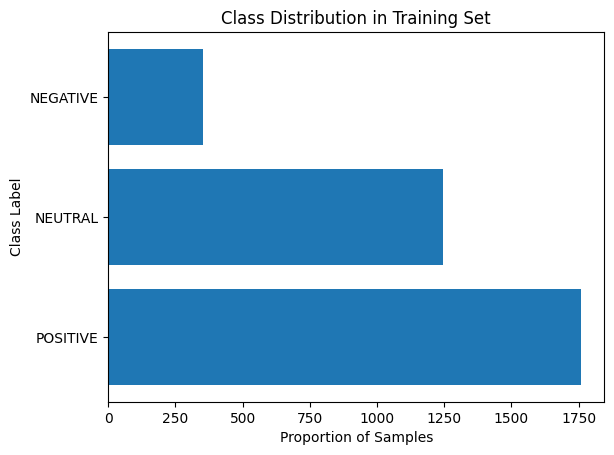

In [ ]:
# example to view the class distribution in the dataset
df_aux = train_dataset.to_pandas()

display(df_aux["labels"].value_counts(normalize=True))

values = df_aux["labels"].value_counts().values
class_labels = df_aux["labels"].value_counts().index
replacement_map = {0: 'NEGATIVE', 1: 'NEUTRAL', 2:'POSITIVE'}
# Create a new list using the map
class_labels = [replacement_map.get(item, item) for item in class_labels]

plt.title("Class Distribution in Training Set")
plt.barh(class_labels, values)
plt.xlabel("Proportion of Samples")
plt.ylabel("Class Label")
plt.show()

## 3. Tune model distilbert-base

### 3.1 Model with unbalance weight

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["DOCUMENT"], padding="max_length", truncation=True)

# Apply tokenizer
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
tokenized_oot = oot_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/827 [00:00<?, ? examples/s]

In [ ]:
#  Define your label mappings (highly recommended for 3-class models)
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
label2id = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}

In [ ]:
def compute_metrics(pred):
    """
    Calcualtes accuracy and f1 score given predictions.

    Args:
        pred (EvalPrediction):
    """
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/traning_args_no_weight"


# Train arguments
training_args = TrainingArguments(
    output_dir=file_path,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch"
)
# train the model
trainer = Trainer(
model=model,
args=training_args,
train_dataset=tokenized_train,
eval_dataset=tokenized_test,
compute_metrics=compute_metrics,
)

In [ ]:
# save the tunning model
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_no_weight"

# Save the model's weights and configuration
trainer.save_model(file_path)

# Save the tokenizer alongside the model
tokenizer.save_pretrained(file_path)

print(f"Model and tokenizer successfully saved to {file_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer successfully saved to /content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_no_weight


In [ ]:
# Check error metrics Train, Validation and Test
pred_output_train = trainer.predict(tokenized_train)
pred_output_test = trainer.predict(tokenized_test)
pred_output_oot = trainer.predict(tokenized_oot)

In [ ]:
# Compare error metrics in different datasets
df_metrics_train = pd.DataFrame([pred_output_train.metrics])
df_metrics_train['dataset'] = 'train'
df_metrics_val = pd.DataFrame([pred_output_test.metrics])
df_metrics_val['dataset'] = 'test'
df_metrics_test = pd.DataFrame([pred_output_oot.metrics])
df_metrics_test['dataset'] = 'oot'

# Combine dataframes
df_metrics = pd.concat([df_metrics_train, df_metrics_val, df_metrics_test], ignore_index=True)
display(df_metrics)

,test_loss,test_model_preparation_time,test_accuracy,test_f1,test_runtime,test_samples_per_second,test_steps_per_second,dataset
0,1.071070,0.0007,0.512668,0.365487,5.2200,642.721,10.153,train
1,1.080241,0.0007,0.444982,0.274064,1.1261,734.391,11.544,test
2,1.073609,0.0007,0.500864,0.360535,0.8189,707.013,12.211,oot


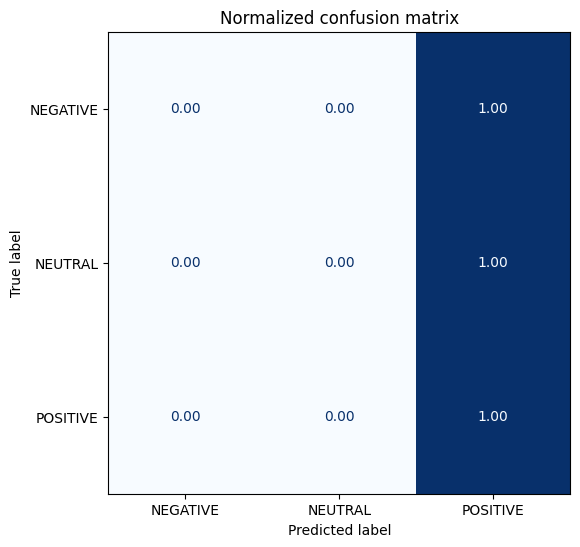

In [ ]:
def plot_confusion_matrix(y_preds, y_true, labels):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

# Confusion matrix test
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
y_test = np.array(tokenized_test["labels"])
y_pred = pred_output_test.predictions.argmax(axis=1)
plot_confusion_matrix(y_pred, y_test, list(id2label.values()))

### 3.2 Model with balance weight

In [ ]:
run = True

if run:
  # --- 1. Calculate the Class Weights ---

  # Extract all the true labels from your training dataset
  train_labels = np.array(tokenized_train["labels"])

  # Use Scikit-Learn to calculate the balanced weights automatically
  class_weights = compute_class_weight(
      class_weight="balanced",
      classes=np.unique(train_labels),
      y=train_labels
  )

  # Convert the weights to a PyTorch tensor and push to your GPU (if available)
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

  print(f"Calculated Class Weights: {weights_tensor}")


  # --- 2. Build the Custom Trainer ---

  class WeightedTrainer(Trainer):
      def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
          # Extract the true labels from the batch
          labels = inputs.pop("labels")

          # Pass the text inputs through the model to get its predictions (logits)
          outputs = model(**inputs)
          logits = outputs.get("logits")

          # Apply the weighted Cross Entropy Loss
          loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)

          # Calculate the actual loss
          loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

          return (loss, outputs) if return_outputs else loss


  # --- 3. Initialize and Train ---

  # Your existing model initialization
  model = AutoModelForSequenceClassification.from_pretrained(
      model_checkpoint,
      num_labels=3,
      id2label=id2label,
      label2id=label2id
  )

  file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/traning_args_weight"

  # Your existing arguments
  training_args = TrainingArguments(
      output_dir=file_path,
      learning_rate=2e-5,
      per_device_train_batch_size=256,
      per_device_eval_batch_size=256,
      num_train_epochs=3,
      weight_decay=0.01,
      eval_strategy="epoch",
  )

  # Use your new WeightedTrainer instead of the default Trainer
  trainer = WeightedTrainer(
      model=model,
      args=training_args,
      train_dataset=tokenized_train,
      eval_dataset=tokenized_test,
      compute_metrics=compute_metrics,
  )

  trainer.train()

# save the tunning model
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_weight"

# Save the model's weights and configuration
trainer.save_model(file_path)

# Save the tokenizer alongside the model
tokenizer.save_pretrained(file_path)

print(f"Model and tokenizer successfully saved to {file_path}")

Calculated Class Weights: tensor([3.1861, 0.8975, 0.6361], device='cuda:0')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.096294,0.405079,0.339132
2,No log,1.067796,0.268440,0.248338
3,No log,1.066906,0.313180,0.316523


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer successfully saved to /content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_weight


In [ ]:
# save the tunning model
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_weight_V2"

# Save the model's weights and configuration
trainer.save_model(file_path)

# Save the tokenizer alongside the model
tokenizer.save_pretrained(file_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_weight_V2/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_weight_V2/tokenizer.json')

In [ ]:
save_directory = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/article_sentiment_results_weight"

# Load your custom fine-tuned model
my_loaded_model = AutoModelForSequenceClassification.from_pretrained(save_directory)

# Load your matching tokenizer
my_loaded_tokenizer = AutoTokenizer.from_pretrained(save_directory)

# 3. Create a new Trainer instance specifically for evaluation/prediction
#eval_trainer = Trainer(model=my_loaded_model)
eval_trainer = trainer

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
# Check error metrics Train, Validation and Test
pred_output_train = eval_trainer.predict(tokenized_train)
pred_output_test = eval_trainer.predict(tokenized_test)
pred_output_oot = eval_trainer.predict(tokenized_oot)

In [ ]:
# Compare error metrics in different datasets
df_metrics_train = pd.DataFrame([pred_output_train.metrics])
df_metrics_train['dataset'] = 'train'
df_metrics_val = pd.DataFrame([pred_output_test.metrics])
df_metrics_val['dataset'] = 'test'
df_metrics_test = pd.DataFrame([pred_output_oot.metrics])
df_metrics_test['dataset'] = 'oot'

# Combine dataframes
df_metrics = pd.concat([df_metrics_train, df_metrics_val, df_metrics_test], ignore_index=True)
display(df_metrics)

,test_loss,test_accuracy,test_f1,test_runtime,test_samples_per_second,test_steps_per_second,dataset
0,1.005293,0.470939,0.472668,4.1978,799.226,3.335,train
1,1.066906,0.313180,0.316523,1.0370,797.509,3.857,test
2,1.012258,0.449050,0.443490,0.7307,792.387,4.106,oot


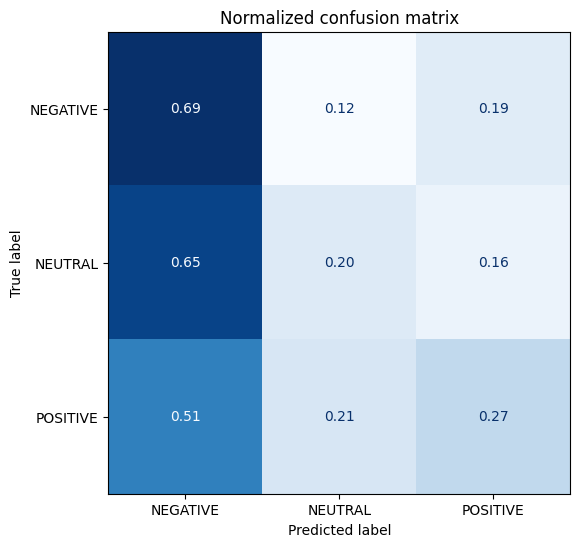

In [ ]:
def plot_confusion_matrix(y_preds, y_true, labels):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

# Confusion matrix test
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
y_test = np.array(tokenized_test["labels"])
y_pred = pred_output_test.predictions.argmax(axis=1)
plot_confusion_matrix(y_pred, y_test, list(id2label.values()))

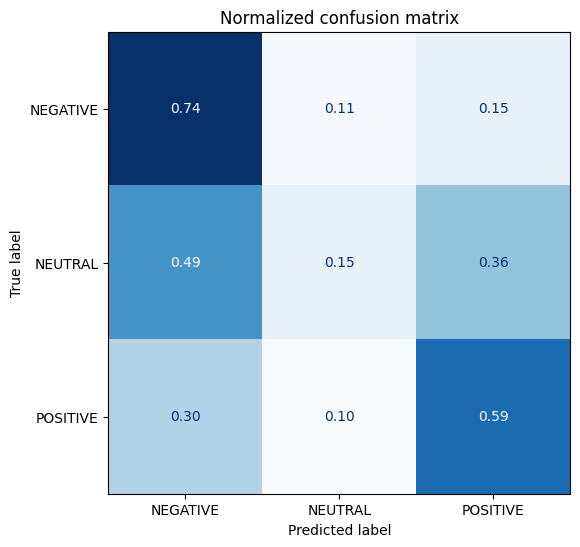

In [ ]:
# Confusion matrix test
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
y_oot = np.array(tokenized_oot["labels"])
y_pred = pred_output_oot.predictions.argmax(axis=1)
plot_confusion_matrix(y_pred, y_oot, list(id2label.values()))

## 4. Estimate Sentiment topic level

 Do the prediction in the total dataset by topic

In [ ]:
# Convert the DataFrame to a Hugging Face Dataset
hf_dataset = Dataset.from_pandas(df_news_AI_clean_topics)
# 3. Verify the conversion
print(hf_dataset)

Dataset({
    features: ['url', 'date', 'title', 'text', 'year', 'month', 'text_word_count', 'title_word_count', 'clean_title', 'clean_text', 'title_word_clean_count', 'text_word_clean_count', 'title_text_clean', 'title_text_clean_count', 'semantic_score', 'Topic_Number', 'Topic_Name', 'Probability'],
    num_rows: 186029
})


In [ ]:
# Change column name
hf_dataset = hf_dataset.rename_column("title_text_clean", "DOCUMENT")
# Apply tokenizer
def tokenize_function_trainer(examples):
    return my_loaded_tokenizer(examples["DOCUMENT"], padding="max_length", truncation=True)

tokenized_df_AI = hf_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/186029 [00:00<?, ? examples/s]

In [ ]:
# Check error metrics Train, Validation and Test
pred_output_data_set = eval_trainer.predict(tokenized_df_AI)

In [ ]:
# Export the sentimenal predeictions as a pickle
file_path = "/content/drive/MyDrive/Colab Notebooks/Final Project NLP/pred_output_data_set.pkl"
# Save lemmatization text
with open(file_path, "wb") as f:
  pickle.dump(pred_output_data_set, f)
  print(f"Successfully saved to {file_path}")

Successfully saved to /content/drive/MyDrive/Colab Notebooks/Final Project NLP/pred_output_data_set.pkl


In [ ]:
len(pred_output_data_set.predictions.argmax(axis=1))

186029

In [ ]:
max_pred_by_row =  pred_output_data_set.predictions.argmax(axis=1)

In [ ]:
# Save results
df_news_AI_clean_topics['sentiment_topic'] = pred_output_data_set.predictions.argmax(axis=1)

In [ ]:
display(df_news_AI_clean_topics['sentiment_topic'].value_counts(normalize=True))

,proportion
sentiment_topic,
2,0.908020
0,0.071424
1,0.020556


In [ ]:
values = df_news_AI_clean_topics['sentiment_topic'].value_counts().reset_index()
value_list = values['count'].values
sentiment_topic = values['sentiment_topic'].values
replacement_map = {0: 'NEGATIVE', 1: 'NEUTRAL', 2:'POSITIVE'}
print(value_list)
print(sentiment_topic)

[168918  13287   3824]
[2 0 1]


,sentiment_topic,count
0,2,168918
1,0,13287
2,1,3824


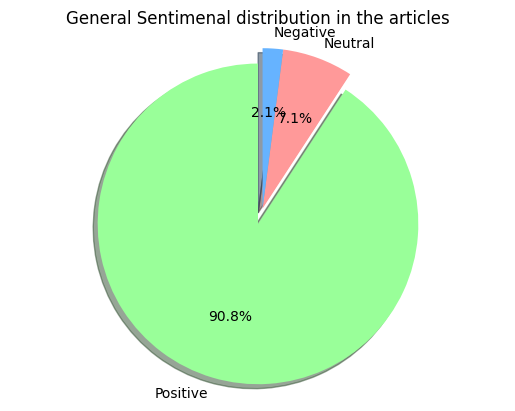

,sentiment_topic,count
0,2,14786
1,0,223
2,1,92


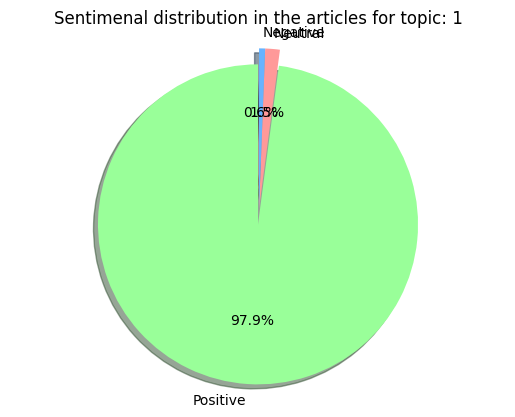

,sentiment_topic,count
0,2,12100
1,0,4080
2,1,838


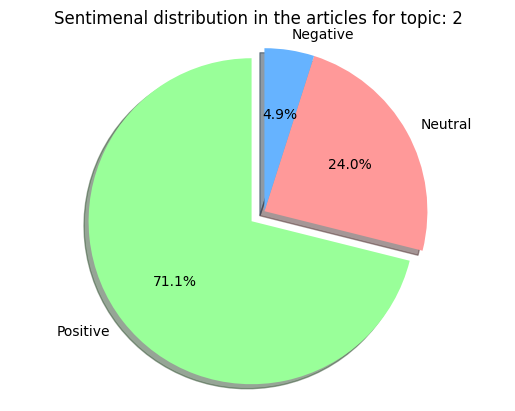

,sentiment_topic,count
0,2,14992
1,0,479
2,1,267


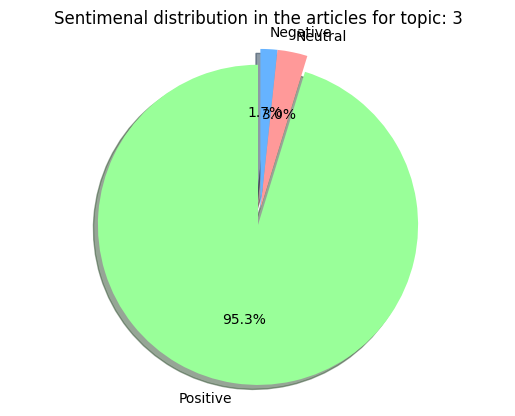

,sentiment_topic,count
0,2,16247
1,0,1632
2,1,307


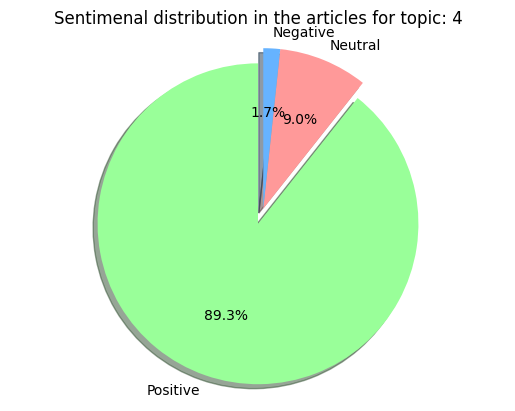

,sentiment_topic,count
0,2,18310
1,0,1517
2,1,616


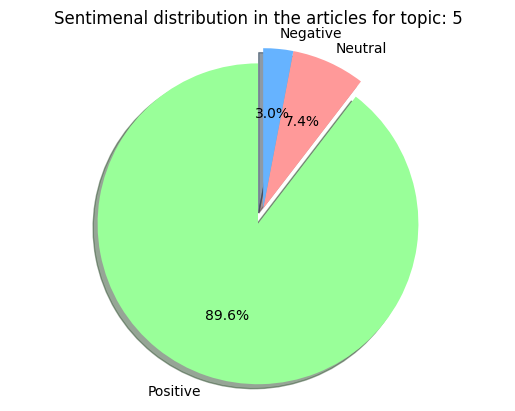

,sentiment_topic,count
0,2,16880
1,0,2250
2,1,270


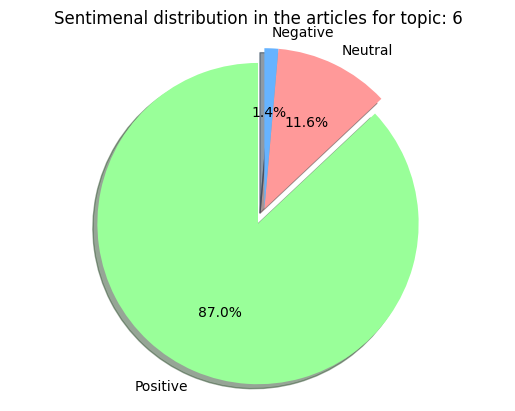

,sentiment_topic,count
0,2,12663
1,0,1123
2,1,598


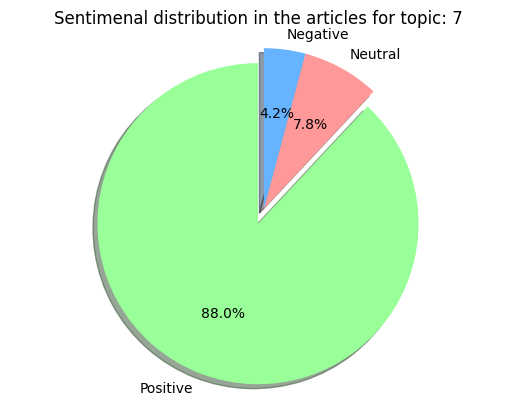

,sentiment_topic,count
0,2,20261
1,0,1683
2,1,733


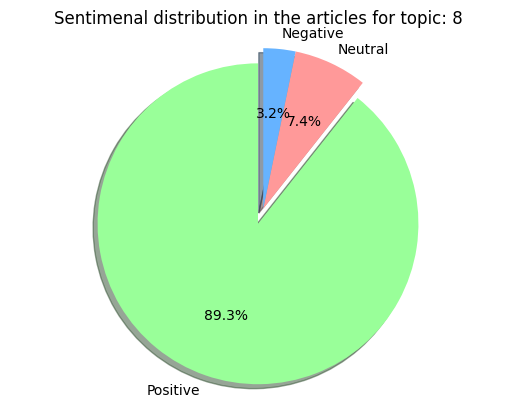

,sentiment_topic,count
0,2,33473
1,0,93
2,1,51


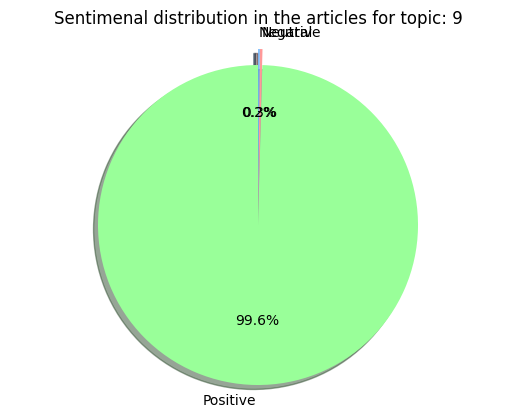

,sentiment_topic,count
0,2,9206
1,0,207
2,1,52


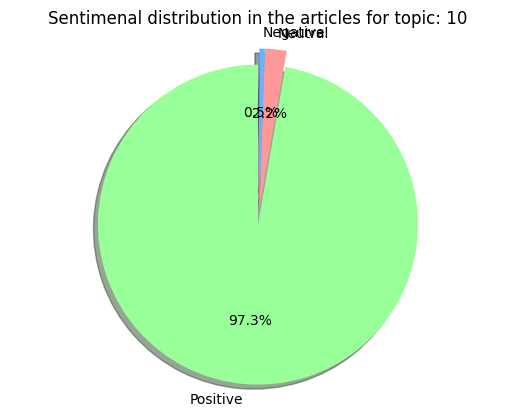

In [ ]:
def pie_chart(value_list, title, No_filtre=True, topic=0):
  if No_filtre:
    values = df_news_AI_clean_topics['sentiment_topic'].value_counts().reset_index()
    value_list = values['count'].values
    sentiment_topic = values['sentiment_topic'].values
    display(values)
  else:
    df_aux = df_news_AI_clean_topics[df_news_AI_clean_topics['Topic_Number']==topic]
    values = df_aux['sentiment_topic'].value_counts().reset_index()
    value_list = values['count'].values
    sentiment_topic = values['sentiment_topic'].values
    display(values)



  # Plot pie chart
  # 1. Prepare the data
  labels = ['Positive', 'Neutral', 'Negative']
  colors = ['#99ff99','#ff9999', '#66b3ff']

  # 2. Highlight a specific slice (optional)
  # The '0.1' pulls the 'Python' slice out slightly. The others (0) stay in place.
  explode = (0.1, 0, 0)

  # 3. Create the pie chart
  plt.pie(value_list,
            explode=explode,
            labels=labels,
            colors=colors,
            autopct='%1.1f%%', # Formats the percentages to one decimal place
            shadow=True,       # Adds a drop shadow
            startangle=90)     # Rotates the start of the chart by 90 degrees

  # 4. Add a title and ensure it's a perfect circle
  plt.title(title)
  plt.axis('equal') # Equal aspect ratio ensures the pie is drawn as a circle.

  # 5. Display the plot
  plt.show()


pie_chart(value_list, 'General Sentimenal distribution in the articles')

for i in range(0,10):
  title = 'Sentimenal distribution in the articles for topic: ' + str(i+1)
  pie_chart(value_list, title, False, i)

## 4. Estimate Sentiment entity level

In [ ]:
df_filtered_entities = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/df_filtered_entities.parquet', engine='pyarrow')

In [ ]:
df_filtered_entities.head()

,index_doc,word,entity,frenqency
0,0,"[##B, ##works Research, BA]","[ORG, ORG, ORG]","[1, 1, 1]"
1,1,"[Werner, Dream Machine]","[ORG, PRODUCT]","[1, 1]"
2,2,"[this Boing Boing ' s Shop, Cha, GPT - 4, Goog...","[ORG, ORG, PRODUCT, ORG, PRODUCT, ORG, PRODUCT...","[1, 1, 2, 2, 1, 1, 1, 1, 1]"
3,3,"[Fund, de China, China, Baidu]","[ORG, ORG, ORG, ORG]","[1, 1, 1, 1]"
4,4,"[Microsoft, ##vidia, Empower Develo, Windows A...","[ORG, ORG, ORG, PRODUCT, PRODUCT, PRODUCT, ORG...","[8, 3, 1, 5, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [ ]:
# Merge both dataframe
initial_rows = len(df_news_AI_clean_topics)
df_news_AI_entity = df_news_AI_clean_topics.copy()
df_news_AI_entity['index'] = df_news_AI_clean_topics.index
df_news_AI_entity = pd.merge(df_news_AI_entity, df_filtered_entities, left_on='index', right_on='index_doc', how='inner')
final_rows = len(df_news_AI_entity)
print(f'Initial rows: {initial_rows}, Final rows: {final_rows}')

Initial rows: 186029, Final rows: 186029


In [ ]:
# Top 20 most common entities
df_exploded = df_news_AI_entity.explode(['word', 'entity', 'frenqency'])

# 2. Ensure the frequency column is treated as numeric integers
df_exploded['frenqency'] = pd.to_numeric(df_exploded['frenqency'])

# 3. Group by 'word' and 'entity', sum the frequencies
frenq_entities = (df_exploded
                   .groupby(['word', 'entity'], as_index=False).agg({'frenqency':'sum','sentiment_topic':'mean'})
                   .sort_values(by='frenqency', ascending=False))



# 4. Reset the index for a clean output
frenq_entities = frenq_entities.reset_index(drop=True)
#total
total = frenq_entities['frenqency'].sum()
frenq_entities['percentage'] = frenq_entities['frenqency'] / total * 100

display(frenq_entities)

,word,entity,frenqency,sentiment_topic,percentage
0,Google,ORG,53603.0,1.804636,2.298477
1,Microsoft,ORG,51985.0,1.752694,2.229098
2,OpenAI,ORG,50664.0,1.599922,2.172454
3,AI,ORG,38622.0,1.825828,1.656098
4,Cha,ORG,35735.0,1.654748,1.532304
...,...,...,...,...,...
236313,E + D (,ORG,1.0,2.000000,0.000043
236314,E - 208,PRODUCT,1.0,2.000000,0.000043
236315,E - 7,PRODUCT,1.0,2.000000,0.000043
236316,E - A,PRODUCT,1.0,2.000000,0.000043


/tmp/ipykernel_38304/4126052409.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')


,word,entity,frenqency,sentiment_topic
0,Google,ORG,53603.0,1.804636
1,Microsoft,ORG,51985.0,1.752694
2,OpenAI,ORG,50664.0,1.599922
3,AI,ORG,38622.0,1.825828
4,Apple,ORG,26393.0,1.840489
5,Open,ORG,25089.0,1.650383
6,PR,ORG,24688.0,1.983750
7,Amazon,ORG,15926.0,1.843370
8,Nvidia,ORG,15313.0,1.855954
9,PRNewswire,ORG,12920.0,1.994381


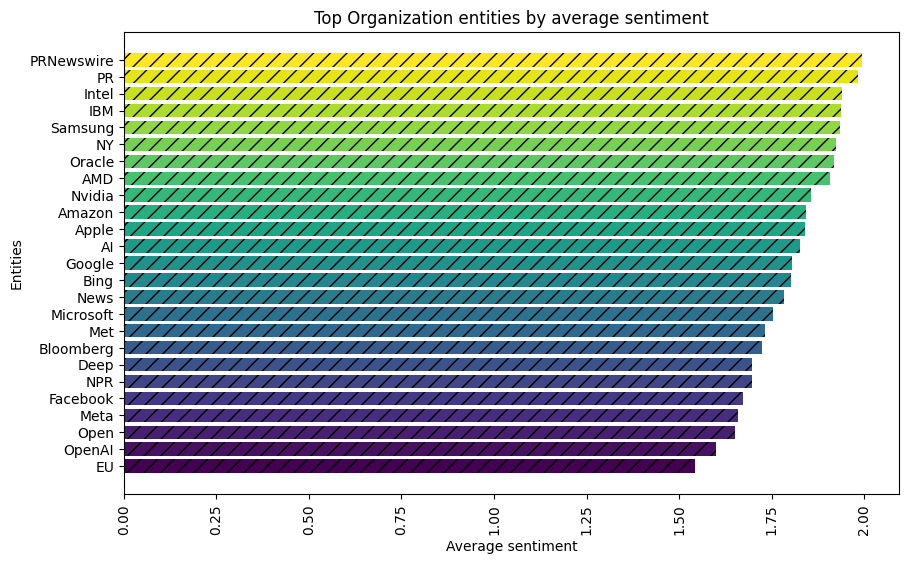

In [ ]:
# Filter only ORG
df_aux = frenq_entities[frenq_entities['entity']=='ORG']
df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')
df_aux = df_aux.groupby(['word','entity']).agg({'frenqency':'sum','sentiment_topic':'mean'}).reset_index()
df_aux = df_aux.sort_values(by='frenqency', ascending=False)

# Remove noise entities
df_aux = df_aux[df_aux['word']!='##I']
df_aux = df_aux[df_aux['word']!='ME']
df_aux = df_aux[df_aux['word']!='Re']
df_aux = df_aux[df_aux['word']!='An']
df_aux = df_aux[df_aux['word']!='PRNews']
df_aux = df_aux[df_aux['word']!='In']
df_aux = df_aux[df_aux['word']!='Cha']
df_aux.reset_index(drop=True, inplace=True)


df_aux = df_aux.head(25)
display(df_aux)

df_aux = df_aux.sort_values(by='sentiment_topic', ascending=True)

num_bars = len(df_aux['word'])
color_gradient = plt.cm.viridis(np.linspace(0, 1, num_bars))
plt.figure(figsize=(10, 6))
# Create the vertical bar plot with colors and a hatch pattern
bars = plt.barh(
    df_aux['word'],
    df_aux['sentiment_topic'],
    color=color_gradient,
    hatch='//' )

plt.title("Top Organization entities by average sentiment")
plt.xlabel("Average sentiment")
plt.ylabel("Entities")
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_38304/3672668189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')


,word,entity,frenqency,sentiment_topic
0,Gemini,PRODUCT,6170.0,1.875613
1,Cha,PRODUCT,4841.0,1.807777
2,GP,PRODUCT,3937.0,1.935620
3,AI,PRODUCT,3365.0,1.954237
4,GPT - 4,PRODUCT,2602.0,1.859438
5,iPhone,PRODUCT,1355.0,1.951351
6,GPU,PRODUCT,1020.0,1.926332
7,Windows 11,PRODUCT,961.0,1.966581
8,Bing,PRODUCT,892.0,1.964824
9,##AI,PRODUCT,880.0,1.927769


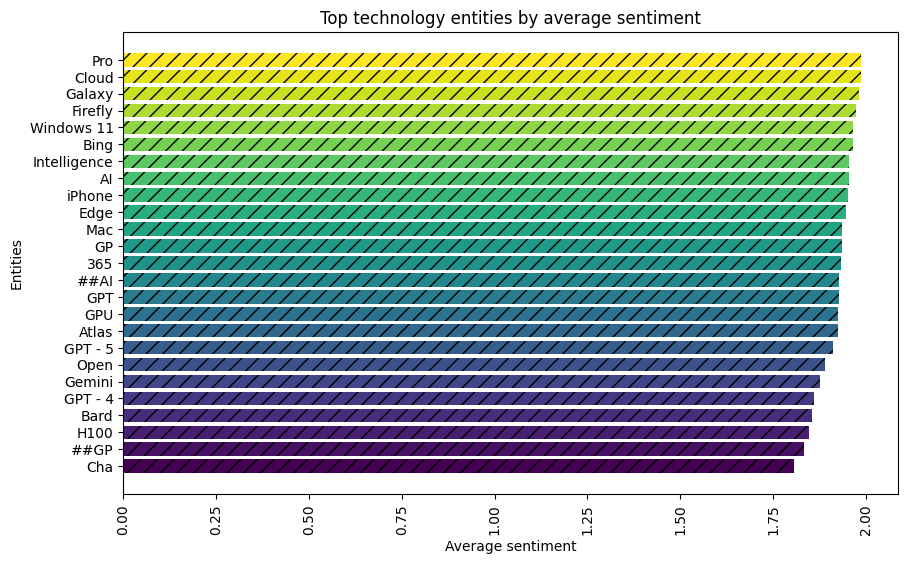

In [ ]:
# Filter only ORG
df_aux = frenq_entities[frenq_entities['entity']=='PRODUCT']
df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')
df_aux = df_aux.groupby(['word','entity']).agg({'frenqency':'sum','sentiment_topic':'mean'}).reset_index()
df_aux = df_aux.sort_values(by='frenqency', ascending=False)

# Remove noise entities
df_aux = df_aux[df_aux['word']!='##I']
df_aux = df_aux[df_aux['word']!='##t']
df_aux = df_aux[df_aux['word']!='the']
df_aux = df_aux[df_aux['word']!='##lot']
df_aux = df_aux[df_aux['word']!='##lot']
df_aux = df_aux[df_aux['word']!='##3']
df_aux = df_aux[df_aux['word']!='##T']
df_aux = df_aux[df_aux['word']!='Pi']
df_aux = df_aux[df_aux['word']!='In']
df_aux = df_aux[df_aux['word']!='##2']
df_aux = df_aux[df_aux['word']!='##VI']
df_aux = df_aux[df_aux['word']!='Co']
df_aux = df_aux[df_aux['word']!='So']
df_aux = df_aux[df_aux['word']!='Re']
df_aux = df_aux[df_aux['word']!='##A']
df_aux.reset_index(drop=True, inplace=True)


df_aux = df_aux.head(25)
display(df_aux)

df_aux = df_aux.sort_values(by='sentiment_topic', ascending=True)

num_bars = len(df_aux['word'])
color_gradient = plt.cm.viridis(np.linspace(0, 1, num_bars))
plt.figure(figsize=(10, 6))
# Create the vertical bar plot with colors and a hatch pattern
bars = plt.barh(
    df_aux['word'],
    df_aux['sentiment_topic'],
    color=color_gradient,
    hatch='//' )

plt.title("Top technology entities by average sentiment")
plt.xlabel("Average sentiment")
plt.ylabel("Entities")
plt.xticks(rotation=90)
plt.show()

## 4. Estimate Sentiment overtime

,year,sentiment_topic
0,2022,1.927978
1,2023,1.850342
2,2024,1.809607
3,2025,1.815344


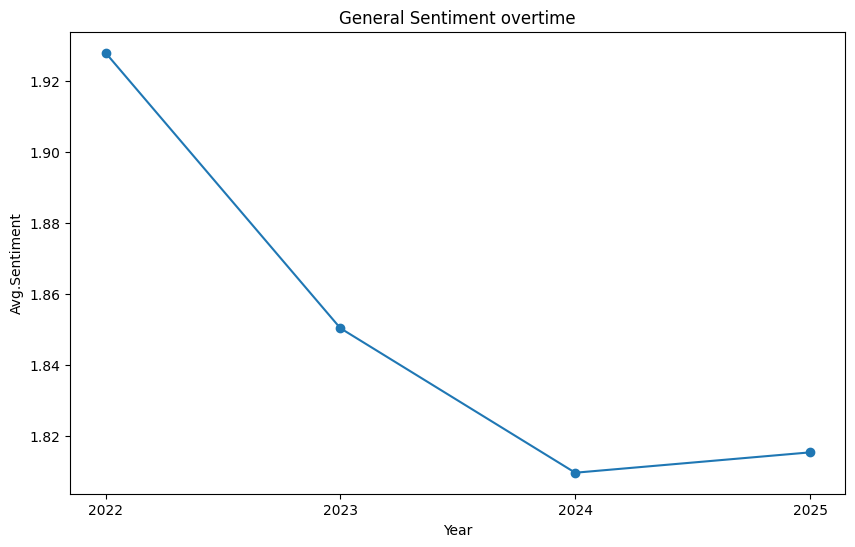

In [ ]:
# Years
df_year = df_news_AI_clean_topics[df_news_AI_clean_topics['year'] != 2026]
df_year = df_year.groupby(['year']).agg({'sentiment_topic':'mean'}).reset_index()
display(df_year)

# Plot
year_list = df_year['year'].unique()
plt.figure(figsize=(10, 6))
plt.plot(df_year['year'], df_year['sentiment_topic'], marker='o', linestyle='-')
plt.title('General Sentiment overtime')
plt.xlabel('Year')
plt.ylabel('Avg.Sentiment')
plt.xticks(year_list)
plt.show()


,year,Topic_Number,sentiment_topic
0,2022,0,1.982727
1,2022,1,1.422627
2,2022,2,1.895050
3,2022,3,1.861411
4,2022,4,1.923664
5,2022,5,1.929078
6,2022,6,1.873288
7,2022,7,1.891274
8,2022,8,1.986980
9,2022,9,1.987780


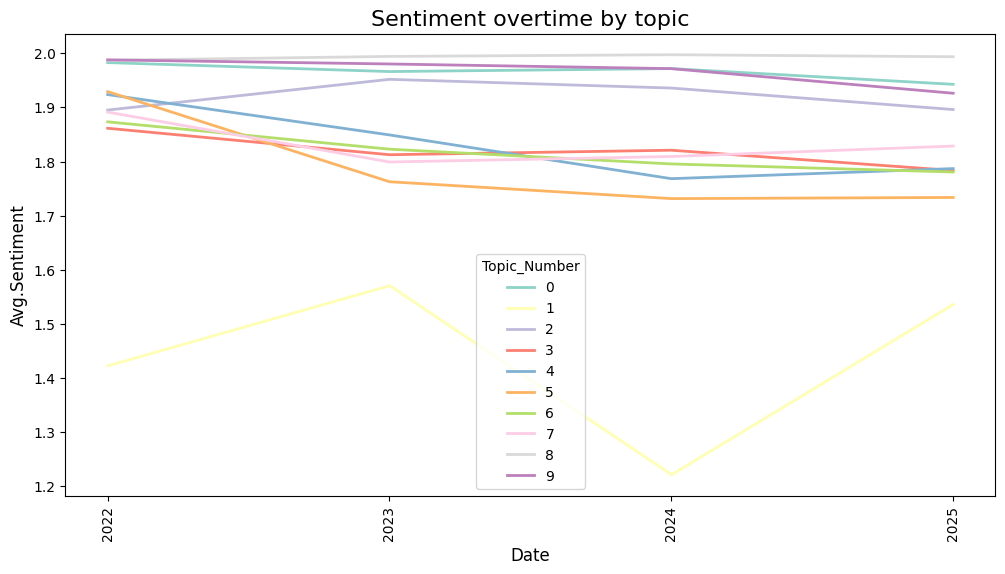

In [ ]:
import seaborn as sns
# Sentiment overtime by topic
df_year_topic = df_news_AI_clean_topics[df_news_AI_clean_topics['year'] != 2026]
df_year_topic = df_year_topic.groupby(['year','Topic_Number']).agg({'sentiment_topic':'mean'}).reset_index()
display(df_year_topic.head(10))


# Plot
# 3. Create the plot
plt.figure(figsize=(12, 6)) # Set the figure size

# 4. Use Seaborn's lineplot
sns.lineplot(data=df_year_topic,
             x='year',
             y='sentiment_topic',
             hue='Topic_Number',    # Differentiates the lines by color
             palette='Set3',
             linewidth=2)

# 5. Customize the chart
plt.title('Sentiment overtime by topic', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Avg.Sentiment', fontsize=12)

# Rotate x-axis dates so they don't overlap
plt.xticks(rotation=90)
plt.xticks(year_list)

# 6. Display the plot
plt.show()


In [ ]:
df_exploded = df_news_AI_entity.explode(['word', 'entity', 'frenqency'])

# 2. Ensure the frequency column is treated as numeric integers
df_exploded['frenqency'] = pd.to_numeric(df_exploded['frenqency'])

# 3. Group by 'word' and 'entity', sum the frequencies
frenq_entities_year = (df_exploded
                   .groupby(['word', 'entity','year'], as_index=False).agg({'frenqency':'sum','sentiment_topic':'mean'})
                   .sort_values(by='frenqency', ascending=False))



# 4. Reset the index for a clean output
frenq_entities_year = frenq_entities_year.reset_index(drop=True)
#total
total = frenq_entities_year['frenqency'].sum()
frenq_entities_year['percentage'] = frenq_entities_year['frenqency'] / total * 100

display(frenq_entities_year)

,word,entity,year,frenqency,sentiment_topic,percentage
0,Microsoft,ORG,2023,25842.0,1.763985,1.108096
1,Google,ORG,2023,21053.0,1.835989,0.902745
2,Cha,ORG,2023,20329.0,1.678825,0.871700
3,OpenAI,ORG,2023,20211.0,1.598712,0.866640
4,PR,ORG,2023,15812.0,1.987239,0.678013
...,...,...,...,...,...,...
313283,##0 / FM,ORG,2023,1.0,2.000000,0.000043
313284,” And Ithaca Shakespeare Company,ORG,2022,1.0,2.000000,0.000043
313285,” Associated Press,ORG,2024,1.0,2.000000,0.000043
313286,” Automotive Industries (,ORG,2024,1.0,2.000000,0.000043


/tmp/ipykernel_38304/483598304.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')


,word,entity,year,frenqency,sentiment_topic
0,Microsoft,ORG,2023,25842.0,1.763985
1,Google,ORG,2023,21053.0,1.835989
2,OpenAI,ORG,2023,20211.0,1.598712
4,OpenAI,ORG,2025,15057.0,1.622317
5,Google,ORG,2024,14681.0,1.767698
6,Microsoft,ORG,2024,13902.0,1.705799
7,Google,ORG,2025,13600.0,1.806971
8,OpenAI,ORG,2024,13528.0,1.550546
10,Apple,ORG,2024,12510.0,1.884328
13,Microsoft,ORG,2025,10019.0,1.766230


<Figure size 1000x600 with 0 Axes>

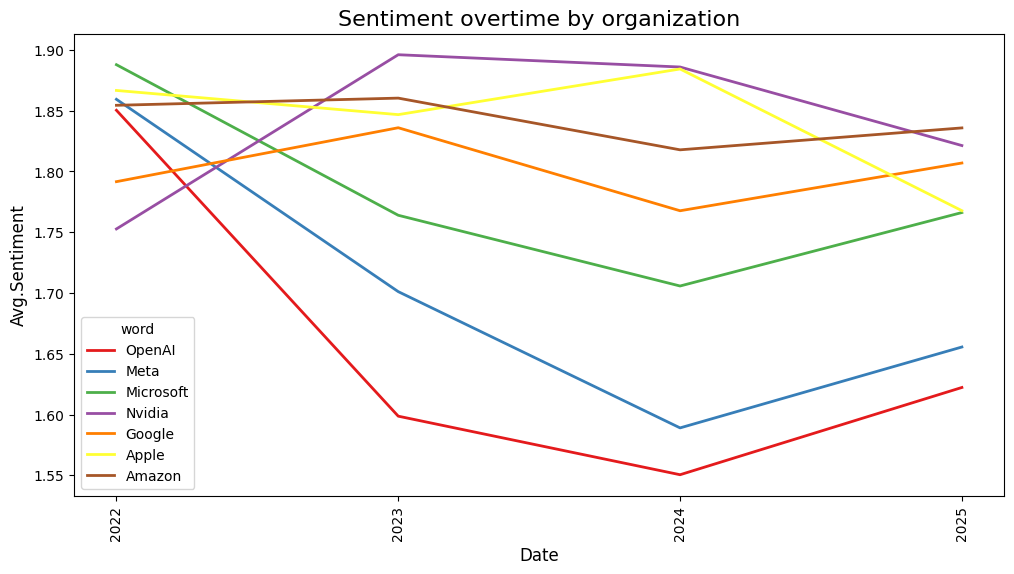

In [101]:
# Filter only ORG
df_aux = frenq_entities_year[frenq_entities_year['entity']=='ORG']
df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')
df_aux = df_aux.groupby(['word','entity','year']).agg({'frenqency':'sum','sentiment_topic':'mean'}).reset_index()
df_aux = df_aux.sort_values(by='frenqency', ascending=False)

# Remove noise entities
df_aux = df_aux[df_aux['word']!='##I']
df_aux = df_aux[df_aux['word']!='ME']
df_aux = df_aux[df_aux['word']!='Re']
df_aux = df_aux[df_aux['word']!='An']
df_aux = df_aux[df_aux['word']!='PRNews']
df_aux = df_aux[df_aux['word']!='In']
df_aux = df_aux[df_aux['word']!='Cha']
df_aux.reset_index(drop=True, inplace=True)

# Filter list_entities
list_entities = ['Google','Microsoft','OpenAI','Apple','Amazon','Nvidia','Meta']
#8	Nvidia	ORG	15313.0	1.855954
df_aux = df_aux[df_aux['word'].isin(list_entities)]
df_aux = df_aux[df_aux['year'] != 2026]
display(df_aux)

df_aux = df_aux.sort_values(by='sentiment_topic', ascending=True)

num_bars = len(df_aux['word'])
color_gradient = plt.cm.viridis(np.linspace(0, 1, num_bars))
plt.figure(figsize=(10, 6))
# Create the vertical bar plot with colors and a hatch pattern
# Plot
# 3. Create the plot
plt.figure(figsize=(12, 6)) # Set the figure size

# 4. Use Seaborn's lineplot
sns.lineplot(data=df_aux,
             x='year',
             y='sentiment_topic',
             hue='word',    # Differentiates the lines by color
             palette='Set1',
             linewidth=2)

# 5. Customize the chart
plt.title('Sentiment overtime by organization', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Avg.Sentiment', fontsize=12)

# Rotate x-axis dates so they don't overlap
plt.xticks(rotation=90)
plt.xticks(year_list)

# 6. Display the plot
plt.show()

/tmp/ipykernel_38304/3090057182.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')


,word,entity,year,frenqency,sentiment_topic
33,Bing,ORG,2023,3817.0,1.817407
80,Gemini,ORG,2025,1458.0,1.842105
91,Gemini,ORG,2024,1378.0,1.765723
188,iPhone,ORG,2024,766.0,1.919512
195,Edge,ORG,2023,735.0,1.986945
427,Bing,ORG,2024,410.0,1.812500
504,Cloud,ORG,2023,361.0,1.995671
621,iPhone,ORG,2025,307.0,1.707547
648,Gemini,ORG,2023,299.0,1.912500
692,Cloud,ORG,2025,282.0,1.802395


<Figure size 1000x600 with 0 Axes>

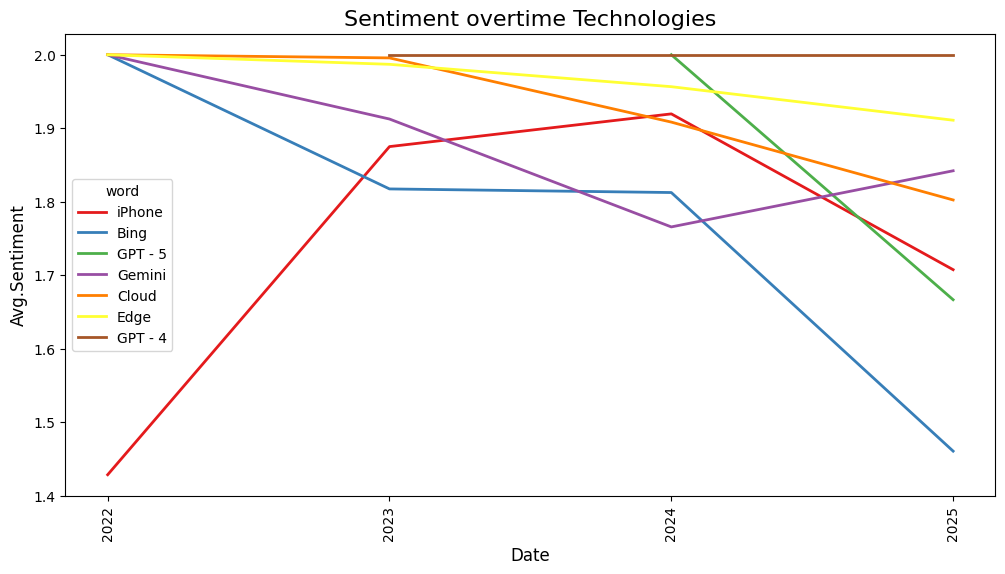

In [ ]:
# Filter only ORG
df_aux = frenq_entities_year[frenq_entities_year['entity']=='ORG']
df_aux['word'] = df_aux['word'].str.replace('##vidia', 'Nvidia')
df_aux = df_aux.groupby(['word','entity','year']).agg({'frenqency':'sum','sentiment_topic':'mean'}).reset_index()
df_aux = df_aux.sort_values(by='frenqency', ascending=False)



# Remove noise entities
df_aux = df_aux[df_aux['word']!='##I']
df_aux = df_aux[df_aux['word']!='##t']
df_aux = df_aux[df_aux['word']!='the']
df_aux = df_aux[df_aux['word']!='##lot']
df_aux = df_aux[df_aux['word']!='##lot']
df_aux = df_aux[df_aux['word']!='##3']
df_aux = df_aux[df_aux['word']!='##T']
df_aux = df_aux[df_aux['word']!='Pi']
df_aux = df_aux[df_aux['word']!='In']
df_aux = df_aux[df_aux['word']!='##2']
df_aux = df_aux[df_aux['word']!='##VI']
df_aux = df_aux[df_aux['word']!='Co']
df_aux = df_aux[df_aux['word']!='So']
df_aux = df_aux[df_aux['word']!='Re']
df_aux.reset_index(drop=True, inplace=True)





# Filter list_entities
list_entities = ['Gemini','GPT - 5', 'GPT - 4','Cloud','iPhone','Bing','Edge']
#8	Nvidia	ORG	15313.0	1.855954
df_aux = df_aux[df_aux['word'].isin(list_entities)]
df_aux = df_aux[df_aux['year'] != 2026]
display(df_aux)

df_aux = df_aux.sort_values(by='sentiment_topic', ascending=True)

num_bars = len(df_aux['word'])
color_gradient = plt.cm.viridis(np.linspace(0, 1, num_bars))
plt.figure(figsize=(10, 6))
# Create the vertical bar plot with colors and a hatch pattern
# Plot
# 3. Create the plot
plt.figure(figsize=(12, 6)) # Set the figure size

# 4. Use Seaborn's lineplot
sns.lineplot(data=df_aux,
             x='year',
             y='sentiment_topic',
             hue='word',    # Differentiates the lines by color
             palette='Set1',
             linewidth=2)

# 5. Customize the chart
plt.title('Sentiment overtime Technologies', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Avg.Sentiment', fontsize=12)

# Rotate x-axis dates so they don't overlap
plt.xticks(rotation=90)
plt.xticks(year_list)

# 6. Display the plot
plt.show()


